# Lab 4: Reinforcement Learning - Part 2

In this lab, we aim to learn how to deal with practical reinforcement learning problems.

We will cover both discrete RL approaches and function approximation.


The lab is divided into 2 parts.
- In **part 1**, we learn the basics of modelling a simple, finite states and action RL problem and how to solve it with Reinforcement Learning.
- In **part 2**, we will tackle a much more complicated problem, i.e., when the input is an image.

_Note_: Part 1 is in a separate notebook.


__Notes about structure__:
- When you need to make changes to code, it is marked with [# -> TODO: ... <-]
- Please answer the marked questions

***
## Deep Reinforcement Learning
***

In this part, we will test how to use function approximation, and specifically Deep Reinforcement Learning, to solve RL problems directly using images as observations.


### The MinAtar Benchmark

For this assignment, we will use the [MinAtar](https://github.com/kenjyoung/MinAtar) benchmark, which offers a simplified version of Atari games.

For part 2, we will focus on the Breakout game:

<div>
    <img src="img/breakout.gif" width="200"/>
</div>

The objective is to break the wall of pixels, at the top of the screen, by making the ball bounce on the players racket, at the bottom of the screen.
The ball is represented with two pixel to give a visual appearance of the direction of the movement, making unnecessary to use a history of frames (frame stacking). This makes the environment fully observable, as each image represents completely the state of the game.

## Task 2.1 - Load Torch and test the environment

First of all we will load the important libraries and create a folder to save the graphs we will create using matplotlib.

In [21]:
%pip install gymnasium minatar


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import torch
import numpy as np
import numpy.typing as npt

import matplotlib.pyplot as plt
from pathlib import Path

# Create a folder for the results
Path("results").mkdir(parents=True, exist_ok=True)


Now we configure Torch and we check if cuda is available. The `set_num_interop_threads` and `set_num_threads` configure the parallelism level of the torch library. For reinforcement learning, setting both variable to zero often gives the best results, particularly for low dimensional observations.

_Note_: that for these small networks GPUs don't offer so much benefit. If you are running the code on the cluster it may be worth to force to use GPUs as it will scale better.

In [23]:
# Set the parallelism level for torch
#torch.set_num_interop_threads(1)
#torch.set_num_threads(1)

# Check if cuda is available
use_cuda = torch.cuda.is_available()

if use_cuda:
    print("GPU with CUDA found, using GPU acceleration")
else:
    print("No GPU found, using CPU computation")


No GPU found, using CPU computation


Now we create the MinatarEnv, from [minatar_env.py](./minatar_env.py). Write a short test loop that sample random actions and visualize the state for 100 timesteps of until an absorbing state has been reached.

We can visualize the images using the `Visualizer` class defined in [visualizer.py](./visualizer.py). remember to close the visualizer after the rendering is done!

_Note_: if you are running this notebook as a Python file, please set `is_notebook` to false.

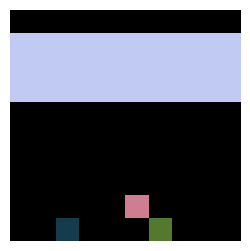

In [24]:
# Create breakout Environment
from minatar_env import MinatarEnv
from visualizer import Visualizer

# Set this variable to false if you are running this code as a Python file and not as a Jupyter notebook
is_notebook = True

env = MinatarEnv('Breakout-v1', use_cuda=use_cuda)
vis = Visualizer(is_notebook=is_notebook)

env.reset()
rgb = env.render()
vis.display(rgb)

for i in range(100):
    action = np.random.choice(env.num_actions)
    next_state, reward, absorbing = env.step(action)
    rgb = env.render()
    vis.display(rgb)

    if absorbing:
        break
vis.close()

## Task 2.2 - Implementing the DQN algorithm

We will now implement the DQN algorithm. To implement DQN we need:

- the replay memory, implemented in [replay_memory.py](./replay_memory.py)
- a policy class, here we will implement a Boltzmann policy
- a network class, for this problem we will implement a small convolutional neural network
- the code for the DQN algorithm

### The Boltzmann Policy

We will start Implementing the Boltzmann policy. This policy assigns the probability of each action proportional to the Q function of each action.

$$P(a | s) = \frac{e^{\beta Q(s, a)}}{\sum_{a' \in A} e^{\beta Q(s, a')}}$$

The (inverse) temperature parameter $\beta$ controls the exploration. with $\beta=0$ the policy will be random, while setting $\beta\to\infty$ will make the policy greedy



In [25]:
import torch.nn as nn

class Boltzmann(object):
    """
    Boltzmann softmax policy.

    """
    def __init__(self, beta):
        """
        Constructor.

        Args:
            beta (float): the inverse of the temperature. As the temperature approaches infinity, the policy becomes
            more and more random. As the temperature approaches 0.0, the policy becomes more and more greedy. Thus, to
            have a greedy policy, set a very high beta, while to have a random policy set beta to 0.

        """
        self._beta = beta
        self._q_function = None

    def __call__(self, state: torch.Tensor) -> npt.NDArray:
        """
        Computes the probability of all actions in the given state.

        Args:
            state: the current state.

        Returns:
            A numpy array representing the probability of all actions in the given state.

        """
        # -> TODO: compute the probability of each action. It will be used for sampling!  <-
        with torch.no_grad():
            q = self._q_function(state)
            p = torch.softmax(self._beta * q, dim=-1)
        return p.numpy()

    def draw_action(self, state: torch.Tensor) -> int:
        """
        Sample an action in the given state.

        Args:
            The current state.

        Returns:
            The sampled action

        """
        p = self(state)

        action = np.random.choice(len(p), p=p)

        return action

    def set_beta(self, beta: float):
        """
        Setter.

        Args:
            beta: the inverse of the temperature distribution.

        """
        self._beta = beta

    def set_q(self, q_function: nn.Module):
        """
        Setter.

        Args:
            q_function: the Q-Function approximator to be used.

        """
        self._q_function = q_function

### The Q network

Now we can implement the Q function approximator as a small convolutional neural network with one convolutional layer, one input layer and one output layer. The neural network should take an input a state and output the q function for every action.

In [26]:
class QConvNetwork(nn.Module):
    def __init__(self, input_shape: tuple, n_output: int, n_out_channels:int, n_features: int,
                 kernel_size: int=3, stride: int=1):
        """
        Constructor.

        Args:
            input_shape: shape of the input (the state);
            n_output: dimensionality of the output vector (number of actions);
            n_out_channels: number of output channels for the convolutional layer;
            n_features: dimensionality of the hidden layers;
            kernel_size: kernel size for the convolutional layers;
            stride: stride for the convolutional layers.

        """
        super().__init__()

        n_input_channels = input_shape[0]

        # One hidden 2D convolution layer:
        # -> TODO: create the convolutional layer  <-
        self.conv = nn.Conv2d(n_input_channels, n_out_channels, kernel_size=kernel_size, stride=stride)

        # Final fully connected hidden layer
        # the number of linear unit depends on the output of the conv
        dim_1 = (input_shape[1] - (kernel_size - 1) - 1) // stride + 1
        dim_2 = (input_shape[2] - (kernel_size - 1) - 1) // stride + 1
        num_linear_units = dim_1 * dim_2 * n_out_channels

        # -> TODO: create the hidden, fully connected layer  <-
        self.fc_hidden = nn.Linear(num_linear_units, n_features)

        # Output layer:
        # -> TODO: create the output layer  <-
        self.output = nn.Linear(n_features, n_output)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the network at the given state.

        Args:
            state: the state to be evaluated.

        Returns:
            The Q-Function for all actions at the given state.

        """

        # First check the dimensionality of the input and add batch dimension if needed.
        if state.dim() == 3:
            state = state.unsqueeze(0)

        # Then, implement the neural network logic
        # -> TODO: implement the neural network logic  <-
        h = torch.relu(self.conv(state))
        h = h.flatten(start_dim=1)
        h = torch.relu(self.fc_hidden(h))
        q = self.output(h)

        return q.squeeze()


### The DQN algorithm

Finally, we can implement the DQN algorithm. Use the provided template and implement the missing methods. Use the replay memory provided in [replay_memory.py](./replay_memory.py)

_Note_: Differently form the original implementation of the DQN algorithm, we will not perform reward clipping.

In [ ]:
from replay_memory import ReplayMemory
from torch.nn.functional import smooth_l1_loss
from copy import deepcopy

class DQN(object):
    """
    Deep Q-Network algorithm.
    "Human-Level Control Through Deep Reinforcement Learning".
    Mnih V. et al. 2015.

    """
    def __init__(self, policy, q_network: nn.Module, gamma: float, learning_rate:float, batch_size: int,
                 target_update_frequency: int, initial_replay_size: int, max_replay_size: int, use_cuda: bool):
        self.policy = policy
        self._gamma = gamma

        self._batch_size = batch_size
        self._target_update_frequency = target_update_frequency

        self._replay_memory = ReplayMemory(initial_replay_size, max_replay_size, use_cuda)

        self._n_updates = 0


        self.q_function = q_network

        if use_cuda:
            self.q_function.cuda()

        self.q_target = deepcopy(self.q_function)
        self._update_target()

        policy.set_q(self.q_function)

        self._optimizer = torch.optim.Adam(self.q_function.parameters(), lr=learning_rate)

    def draw_action(self, state: torch.Tensor) -> int:
        """
        Draws an action from the policy

        Args:
            state: the current state.

        Returns:
            The sampled action.

        """

        return self.policy.draw_action(state)

    def fit(self, dataset: list):
        """
        Updates the Q-function

        Args:
            dataset: a list of transitions to use to update the approximator.

        """
        # -> TODO: implement the neural network logic  <-
        self._replay_memory.add(dataset)
        if self._replay_memory.initialized:
            # Sample a batch from the replay memory
            state, action, reward, next_state, absorbing, _ = self._replay_memory.get(self._batch_size) # -> TODO: implement <-

            # Compute the q function target
            q_next = self._next_q(next_state, absorbing)
            q = reward + self._gamma * q_next # -> TODO: implement <-

            # Train the q function
            self._train_q_function(state, action, q)

            # Update the target network
            # -> TODO: implement <-
            self._n_updates += 1
            if self._n_updates % self._target_update_frequency == 0:
                self._update_target()

    def _next_q(self, next_state: torch.Tensor, absorbing: torch.Tensor):
        """
        Computes the Q-Value for the next state.

        Args:
            next_state: a matrix containing all the next states;
            absorbing: the vector of absorbing flags, signaling if the next state is absorbing.

        Returns:
             A vector of Q-values, one for each next state in the input matrix.

        """
        with torch.no_grad():
            return self.q_target(next_state).max(dim=1)[0] * (1.0 - absorbing.float()) # -> TODO: compute Q in the next state. take care of the absorbing states! <-

    def _train_q_function(self, state: torch.Tensor, action: torch.Tensor, q:torch.Tensor):
        """
        Perform one gradient step to train the Q-function.

        Args:
            state: a matrix containing all the states;
            action: a vector of the taken actions;
            q: a vector of the target Q-values computed for each input state and action.

        """
        # Compute the Q-function at the current state and action
         # -> TODO: implement <-
        q_state_action = self.q_function(state).gather(1, action.unsqueeze(1)).squeeze(1)

        # Compute the loss
        loss = smooth_l1_loss(q_state_action, q)

        # Perform an optimization step
        # Remember to zero out the gradient!
        # -> TODO: implement <-
        self._optimizer.zero_grad()
        loss.backward()
        self._optimizer.step()

    def _update_target(self):
        self.q_target.load_state_dict(self.q_function.state_dict())

## Task 2.3 - Run a RL experiment

here we will run the RL experiment. The code will be very similar to the one in part 1, however, this time we will log:
- J, the expected discounted return
- V, the value function of the greedy policy computed in the initial state
- L, the episode length

### Test episode

Exactly as the function in part 1, but logging different data.

In [ ]:
def test_episode(env, agent, vis=None):
    """
    Function to test the performance of the agent in the environment for a single episode.

    Args:
        env: the environment;
        agent: the agent;
        vis: the visualizer class: if none, no visualization will happen.

    Returns:
        The expected discounted return J,
        the value function on the initial state V,
        and the episode length L.

    """
    J = 0
    L = 0

    state = env.reset()

    V = agent.q_function(state).max().cpu().detach().numpy()

    if vis:
        rgb = env.render()
        vis.display(rgb)

    for t in range(env.horizon):
        # Single step
        # -> TODO: implement <-

        # Accumulate the expected discounted return
        # -> TODO: implement <-

        # rendering functionality for debug purposes
        if vis:
            rgb = env.render()
            vis.display(rgb)

        # break the episode if an absorbing state is reached
        if absorbing:
            break

        state = next_state

    return J, V, L

### Test Episodes

Just runs a test episode function for multiple episodes

In [ ]:
def test_episodes(env, agent, n_episodes: int, render: bool=False):
    """
    Function to test the performance of the agent in the environment.

    Args:
        env: the environment;
        agent: the agent;
        n_episodes: number of test episodes;
        render: whether to call the rendering functionality or not.

    Returns:
        The expected discounted return J,
        the value function on the initial state V,
        and the episode length L.

    """
    J_list = list()
    V_list = list()
    L_list = list()

    vis = Visualizer(is_notebook=is_notebook) if render else None

     # -> TODO: implement the for loop running the episodes <-

    if render:
        vis.close()

    # -> TODO: compute average metrics <-
    J = _
    V = _
    L = _

    return J, V, L

### Learn steps
Similar function as in part 1, but with some key modifications:

- we need to collect a dataset of transitions. Each transition is a tuple $\langle s,a,r,s',\text{absorbing},\text{last}\rangle$
- we need to call the fit function every `n_steps_per_fit`


In [ ]:
def learn_steps(env, agent, n_steps: int, n_steps_per_fit: int):
    """
    Function to run a Reinforcement Learning agent for a number of learning steps in an environment.

    Args:
        env: the environment;
        agent: the agent;
        n_steps: the number of learning steps to run;
        n_steps_per_fit: the number of learning steps between each call of the fit function.
    """
    last = True
    state = None
    episodes_steps = 0

    dataset = list()

    # Learning steps
    for t in range(n_steps):
        # Handle reset state
        if last:
            last = False
            state = env.reset()
            episodes_steps = 0

        # Single learning step
        # -> TODO: implement <-

        # Check if episode is complete or not
        # -> TODO: implement <-

        # Store transition in a tuple and add to the dataset
        # -> TODO: implement <-

        # Call fit function on the dataset when necessary (every n_step_per_fit)
        # -> TODO: implement <-

        # Update your current state
        state = next_state


### The experiment function
This function is very similar to the one in part 1 but with different logging.

In [ ]:
def experiment(seed, alg_class, n_epochs: int, n_steps: int, n_steps_per_fit: int, n_episodes_test: int,
               verbose=False, render=False, render_frequency=25):
    """
    Function to run a full RL experiment.

    Args:
        seed: the random seed;
        n_epochs: the number of epochs;
        n_steps: the number of learning steps;
        n_steps_per_fit: the number of learning steps between each call of the fit function;
        n_episodes_test: the number of test episodes for agent evaluation;
        verbose: if true, the function will print the learning progress during learning;
        render: if true, the function will render the evaluation episodes;
        render_frequency: number of epochs between rendering of the environment.

        Returns:
            The expected discounted return J,
            the value function on the initial state V,
            and the episode length L.

    """
    # Set seeds
    np.random.seed(seed)
    torch.manual_seed(seed)

    # create environment
    game_name = 'Breakout-v1'
    env = MinatarEnv(game_name, use_cuda=use_cuda)

    # create Policy
    beta=0
    policy = Boltzmann(beta)

    # Create Q-network
    n_out_channels = 16
    n_features = 128
    q_network = QConvNetwork(env.state_shape, env.num_actions, n_out_channels, n_features)

    # Create Agent
    gamma = 0.99
    learning_rate= 2.5e-4
    batch_size=32
    target_update_frequency = 1000
    initial_replay_size = 5000
    max_replay_size = 100000

    agent = alg_class(policy, q_network, gamma, learning_rate, batch_size,
                      target_update_frequency, initial_replay_size, max_replay_size, use_cuda=use_cuda)

    # learning loop
    J_list = list()
    V_list = list()
    L_list = list()

    # test episodes
    J, V, L = test_episodes(env, agent, n_episodes_test, render=render)

    J_list.append(J)
    V_list.append(V)
    L_list.append(L)

    if verbose:
        print(f'Epoch: {0}\t J: {J:.4f},\t V: {V:.4f},\t L: {L}')

    for ep in range(n_epochs):
        # decrease the exploration
        # -> TODO: implement <-

        # learn steps
        learn_steps(env, agent, n_steps, n_steps_per_fit)

        # test steps
        needs_rendering = (ep+1) % render_frequency == 0
        J, V, L = test_episodes(env, agent, n_episodes_test, render=render and needs_rendering)
        J_list.append(J)
        V_list.append(V)
        L_list.append(L)

        if verbose:
            print(f'Epoch: {ep+1}\t J: {J:.4f},\t V: {V:.4f},\t L: {L}')

    return np.array(J_list), np.array(V_list), np.array(L_list)

### Running the DQN experiment

Now we can use our codebase and run a DQN experiment. Set the render flag to `True` to visualize the policy learned at given epochs

_Note_: the whole training can take too long. for testing reduce the number of epochs to 10 or less.

In [ ]:
render = True
J, V, L = experiment(seed=0, alg_class=DQN, n_epochs=50, n_steps=10000, n_steps_per_fit=4, n_episodes_test=5,
                     verbose=True, render=render)

ValueError: optimizer got an empty parameter list

We can now visualize the experiment results with Matplotlib. What do you notice?

_Note_: you can tune a bit the parameters, but learning from image observation can be difficult and the learning process can be unstable, due to exploration. Look at the overall trend.

In [ ]:
fig, ax  = plt.subplots(1, 3)

# -> TODO: generate three subplots for the metrics J, V and L <-

plt.savefig('results/test_dqn.png')

plt.show()

## Task 2.4 - Double DQN
Now we implement [Double DQN](https://arxiv.org/abs/1509.06461). This algorithm is a simple extension of DQN, but it modifies the computation of the Q-function target.

The objective of Double DQN is to reduce the overestimation bias, using an approximation of the [Double Q-learning](https://proceedings.neurips.cc/paper_files/paper/2010/file/091d584fced301b442654dd8c23b3fc9-Paper.pdf) approach.

As in DQN, the Q value of the next state is computed using the target network. However, differently from DQN, it uses the online network to compute the max action, decoupling the choice of the max action with the value of the target network.

In [ ]:
class DoubleDQN(DQN):
    """
    Double DQN algorithm.
    "Deep Reinforcement Learning with Double Q-Learning".
    Hasselt H. V. et al. 2016.

    """
    def _next_q(self, next_state: torch.Tensor, absorbing: torch.Tensor):
        with torch.no_grad():
            # -> TODO: implement the next q function for Double DQN <-
            pass

We can now test the algorithm too

In [ ]:
render = True
J, V, L = experiment(seed=0, alg_class=DoubleDQN, n_epochs=50, n_steps=10000, n_steps_per_fit=4, n_episodes_test=5,
                     verbose=True, render=render)

And visualize the results using Matplotlib

In [ ]:
fig, ax  = plt.subplots(1, 3)

# -> TODO: generate three subplots for the metrics J, V and L <-

plt.savefig('results/test_double_dqn.png')
plt.show()

## Task 2.5 - Comparison of the two algorithms using multiple seeds

Finally, we can run the two algorithm over multiple seed.

To speed up the computation, we will use the joblib library, which allows to run the experiment function over multiple processes.

_Note_: running this experiments can take up a lot of time. You can run the code in the cluster. You can run the full notebook (see assignment 3) or you can export this notebook as a Python file. If you run in the cluster as a Python file, comment the experiments above to avoid useless computation. Also, remember to comment the visualization to avoid crashes. The resulting plot will be saved in the "results" folder.


In [ ]:
import time
import datetime
from joblib import Parallel, delayed
from itertools import product

n_seeds = 5
alg_classes = [DQN, DoubleDQN]

print('Running experiments in batch')

# Starts a counter
start_time = time.perf_counter()

# Using joblib to execute learning in parallel
out = Parallel(n_jobs=-1)(
    delayed(experiment)(
        seed=seed,
        alg_class=alg_class,
        n_epochs=50,
        n_steps=10000,
        n_steps_per_fit=4,
        n_episodes_test=5
    )
    for alg_class, seed in product(alg_classes, range(n_seeds))
)

# Compute elapsed time
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f'Runs completed. Elapsed time: {str(datetime.timedelta(seconds=elapsed_time))}')

We now collect the results in an appropriate data structure.

_Note_:  joblib organizes the output in order of submission. Thus, for the code above you will have the different seeds for the same algorithm one after the other.

In [ ]:
result_dict = dict()

for i, alg_class in enumerate(alg_classes):
    result_seeds = out[i*n_seeds:(i+1)*n_seeds]
    J = np.array([o[0] for o in result_seeds])
    V = np.array([o[1] for o in result_seeds])
    L = np.array([o[2] for o in result_seeds])

    result_dict[alg_class.__name__] = {'J': J, 'V': V, 'L': L}

Now we can visualize the results. Plot the mean and confidence interval for J, V, and L, exactly as done in part 1.

What do you notice in the results?

In [ ]:
from plot import plot_mean_conf

fig, ax  = plt.subplots(1, 3)

for alg_name, results in result_dict.items():
    # -> TODO: generate three subplots for the metrics J, V and L with mean and confidence intervals <-
    pass
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), frameon=False, ncol=2)

plt.savefig('results/test_breakout.png')
plt.show()
